In [69]:
import pandas as pd
import numpy as np


In [70]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [71]:
import numpy as np

SEQ_LEN = 12

features = [
'voltage_mean',
'voltage_std',
'voltage_max',
'voltage_min',
'temperature_mean',
'temperature_max',
'capacity',
'capacity_fade',
'cycle_number'
]

target = 'SOH'


def create_sequences(df):

    X = []
    y = []

    for cell in df['cell_id'].unique():

        cell_data = df[df['cell_id'] == cell]

        X_cell = cell_data[features].values
        y_cell = cell_data[target].values

        for i in range(len(cell_data) - SEQ_LEN):

            X.append(X_cell[i:i+SEQ_LEN])
            y.append(y_cell[i+SEQ_LEN])

    return np.array(X), np.array(y)

In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [73]:
X_train, y_train = create_sequences(train)

X_test, y_test = create_sequences(test)

In [74]:
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

In [75]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train_xgb, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [76]:
from sklearn.metrics import mean_absolute_error

y_pred_xgb = model_xgb.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print("XGBoost Test MAE:", mae_xgb)

XGBoost Test MAE: 0.009552501195624482


In [77]:
y_true = []

for cell in test['cell_id'].unique():
    
    cell_data = test[test['cell_id'] == cell]
    
    y_true.extend(cell_data['SOH'].values[SEQ_LEN:])

y_true = np.array(y_true)

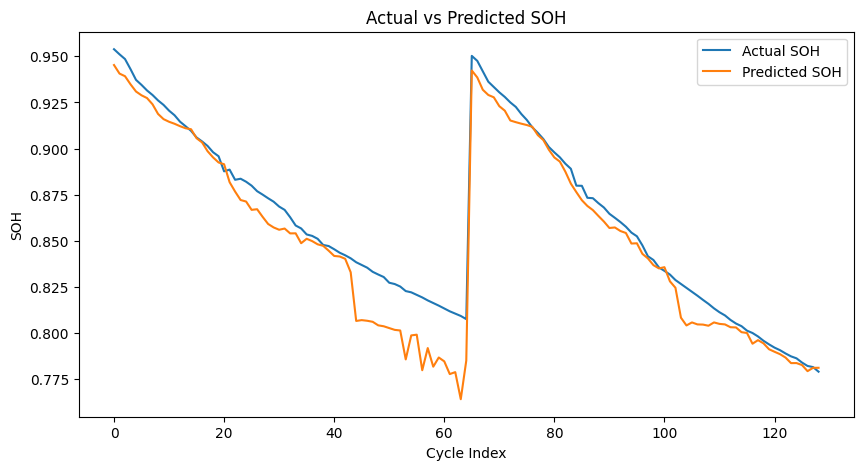

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_true, label="Actual SOH")
plt.plot(y_pred_xgb, label="Predicted SOH")

plt.xlabel("Cycle Index")
plt.ylabel("SOH")
plt.title("Actual vs Predicted SOH")

plt.legend()

plt.show()